# Deep Reinforcement Learning: DQN for LunarLander-v3

This notebook develops a **Deep Q-Network (DQN)** agent for `LunarLander-v3`. It starts from the supplied `deep_rl` code but implements the main algorithm directly so every important step is visible.

Topics covered: LunarLander state/action/reward, DQN equations, neural-network architecture, epsilon-greedy exploration, replay memory, target network, a complete numerical update, training, convergence metrics, evaluation, model saving/loading, and video generation.

## 1. Environment

The state has eight values:

$$
S_t=[x,\ y,\ v_x,\ v_y,\ \theta,\ \dot{\theta},\ c_L,\ c_R]
$$

| Index | Meaning |
|---:|---|
| 0 | horizontal position |
| 1 | vertical position |
| 2 | horizontal velocity |
| 3 | vertical velocity |
| 4 | lander angle |
| 5 | angular velocity |
| 6 | left-leg contact |
| 7 | right-leg contact |

There are four discrete actions:

$$A_t\in\{0,1,2,3\}$$

| Action | Meaning |
|---:|---|
| 0 | do nothing |
| 1 | fire left orientation engine |
| 2 | fire main engine |
| 3 | fire right orientation engine |

The environment reward encourages approaching the pad with low speed and low tilt, rewards leg contact, penalizes engine use, gives a large negative reward for crashing, and a large positive reward for a safe landing. A score of about **200 or greater** is the usual solved-score reference.

## 2. Why DQN?

A Q-table is impractical because most LunarLander state variables are continuous. DQN replaces the table with a neural network:

$$
\boxed{Q(s,a;\theta)\approx Q^*(s,a)}
$$

For one state, the network returns

$$
Q(S_t,\cdot;\theta)=
[Q(S_t,0),Q(S_t,1),Q(S_t,2),Q(S_t,3)]
$$

and the greedy action is

$$
\boxed{A_t=\arg\max_a Q(S_t,a;\theta)}
$$

## 3. Network architecture

The supplied network is retained:

$$
\boxed{8\rightarrow64\rightarrow64\rightarrow64\rightarrow4}
$$

The hidden layers use ReLU and the four output neurons use linear activation. Each output is the estimated Q-value of one action.

## 4. DQN target, prediction, and TD error

DQN uses an **online network** $Q(s,a;\theta)$ and a **target network** $Q(s,a;\theta^-)$.

For transition $(S_t,A_t,R_{t+1},S_{t+1})$:

$$
\boxed{
Y_t=R_{t+1}+\gamma(1-D_t)\max_{a'}Q(S_{t+1},a';\theta^-)
}
$$

where $D_t=1$ for a terminal transition and $0$ otherwise.

The prediction for the action actually taken is

$$
\boxed{\hat Q_t=Q(S_t,A_t;\theta)}
$$

and

$$
\boxed{\delta_t=Y_t-\hat Q_t}
$$

The optimizer updates $\theta$ so the prediction moves toward the target.

## 5. Complete one-step calculation

Suppose

$$Q(S_t,\cdot;\theta)=[2.10,\ 3.40,\ 1.80,\ 2.70].$$

With greedy action selection:

$$A_t=\arg\max_a Q(S_t,a)=1$$

and therefore

$$\hat Q_t=3.40.$$

Assume

$$R_{t+1}=5$$

and the target network gives

$$Q(S_{t+1},\cdot;\theta^-)=[3.20,\ 2.80,\ 4.10,\ 3.60].$$

Then

$$\max_{a'}Q(S_{t+1},a';\theta^-)=4.10.$$

With $\gamma=0.99$ and a nonterminal transition:

$$
Y_t=5+0.99(4.10)=5+4.059=\boxed{9.059}.
$$

The TD error is

$$
\delta_t=9.059-3.40=\boxed{5.659}.
$$

For a terminal transition, $(1-D_t)=0$, so

$$\boxed{Y_t=R_{t+1}}.$$

## 6. Experience replay and target network

Transitions are stored in replay memory:

$$
\mathcal D=\{(s,a,r,s',d)\}.
$$

A random mini-batch is sampled for learning. This reuses experience and reduces the strong correlation between consecutive transitions.

The replay capacity is

$$100{,}000$$

and the mini-batch size is

$$64.$$

The target network is synchronized periodically:

$$
\boxed{\theta^-\leftarrow\theta}
$$

every 1,000 environment steps.

## 7. Epsilon-greedy exploration

$$
A_t=
\begin{cases}
\text{random action}, & \text{with probability }\epsilon\\
\arg\max_a Q(S_t,a;\theta), & \text{with probability }1-\epsilon
\end{cases}
$$

The supplied settings are retained:

$$\epsilon_0=1.0,\qquad \epsilon_{\min}=0.01.$$

The original decay value `1.005` is implemented as

$$
\boxed{
\epsilon\leftarrow
\max\left(\epsilon_{\min},\frac{\epsilon}{1.005}\right)
}
$$

after each episode.

## 8. Colab setup

In [9]:
%pip -q install swig
%pip -q install "gymnasium[box2d]" imageio imageio-ffmpeg

In [10]:
import os, random
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import gymnasium as gym
import tensorflow as tf

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from IPython.display import display, Video

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Gymnasium:", gym.__version__)

TensorFlow: 2.21.0
Gymnasium: 1.3.0


## 9. Inspect LunarLander

In [11]:
env = gym.make("LunarLander-v3")
state, info = env.reset(seed=SEED)

print("Initial state:", state)
print("State shape:", env.observation_space.shape)
print("Action space:", env.action_space)
print("Number of actions:", env.action_space.n)

env.close()

Initial state: [ 0.00229702  1.4181306   0.2326471   0.3204666  -0.00265488 -0.05269805
  0.          0.        ]
State shape: (8,)
Action space: Discrete(4)
Number of actions: 4


## 10. Build the Q-network

In [12]:
def build_q_network():
    state_input = Input(shape=(8,), name="state")
    x = Dense(64, activation="relu")(state_input)
    x = Dense(64, activation="relu")(x)
    x = Dense(64, activation="relu")(x)
    q_values = Dense(4, activation="linear", name="q_values")(x)
    return Model(state_input, q_values, name="LunarLander_DQN")

demo_network = build_q_network()
demo_network.summary()

Model: "LunarLander_DQN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ state (InputLayer)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_values (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,156 (35.77 KB)

 Trainable params: 9,156 (35.77 KB)

 Non-trainable params: 0 (0.00 B)

## 11. Replay buffer

In [13]:
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((
            np.asarray(state, dtype=np.float32),
            int(action),
            float(reward),
            np.asarray(next_state, dtype=np.float32),
            float(done)
        ))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = map(np.array, zip(*batch))
        return (
            states.astype(np.float32),
            actions.astype(np.int32),
            rewards.astype(np.float32),
            next_states.astype(np.float32),
            dones.astype(np.float32)
        )

    def __len__(self):
        return len(self.buffer)

## 12. DQN agent

Your original code used `learn_after_steps=4`. A batch of 64 cannot be sampled after only four stored transitions, so this portfolio version uses a **1,000-transition replay warm-up** before gradient updates begin.

The other main settings are preserved:

- learning rate = `0.0005`
- $\gamma=0.99$
- replay size = `100000`
- epsilon = `1.0 → 0.01`
- epsilon decay divisor = `1.005`
- target update = every `1000` environment steps

Huber loss and gradient clipping are added for more stable neural-network training.

In [14]:
class DQNAgent:
    def __init__(
        self,
        learning_rate=0.0005,
        gamma=0.99,
        replay_size=100_000,
        min_replay_size=1_000,
        epsilon=1.0,
        min_epsilon=0.01,
        epsilon_decay=1.005,
        target_update_steps=1_000,
        gradient_clip_norm=10.0
    ):
        self.gamma = gamma
        self.epsilon = epsilon
        self.min_epsilon = min_epsilon
        self.epsilon_decay = epsilon_decay
        self.min_replay_size = min_replay_size
        self.target_update_steps = target_update_steps
        self.gradient_clip_norm = gradient_clip_norm

        self.replay = ReplayBuffer(replay_size)

        self.q_network = build_q_network()
        self.target_network = build_q_network()
        self.target_network.set_weights(self.q_network.get_weights())

        self.optimizer = Adam(learning_rate=learning_rate)
        self.loss_fn = tf.keras.losses.Huber()

        self.environment_steps = 0
        self.gradient_steps = 0

    def select_action(self, state, training=True):
        if training and np.random.random() < self.epsilon:
            return np.random.randint(4)

        s = tf.convert_to_tensor(
            np.asarray(state, dtype=np.float32)[None, :],
            dtype=tf.float32
        )
        q = self.q_network(s, training=False)
        return int(tf.argmax(q[0]).numpy())

    def remember(self, s, a, r, s_next, done):
        self.replay.add(s, a, r, s_next, done)

    def train_step(self, batch_size=64):
        if len(self.replay) < max(self.min_replay_size, batch_size):
            return None

        states, actions, rewards, next_states, dones = self.replay.sample(batch_size)

        states = tf.convert_to_tensor(states, dtype=tf.float32)
        next_states = tf.convert_to_tensor(next_states, dtype=tf.float32)
        rewards = tf.convert_to_tensor(rewards, dtype=tf.float32)
        dones = tf.convert_to_tensor(dones, dtype=tf.float32)
        actions = tf.convert_to_tensor(actions, dtype=tf.int32)

        next_q = self.target_network(next_states, training=False)
        max_next_q = tf.reduce_max(next_q, axis=1)

        targets = rewards + self.gamma * (1.0 - dones) * max_next_q

        with tf.GradientTape() as tape:
            q_all = self.q_network(states, training=True)
            indices = tf.stack(
                [tf.range(batch_size, dtype=tf.int32), actions],
                axis=1
            )
            predicted_q = tf.gather_nd(q_all, indices)
            loss = self.loss_fn(targets, predicted_q)

        gradients = tape.gradient(loss, self.q_network.trainable_variables)
        gradients, grad_norm = tf.clip_by_global_norm(
            gradients, self.gradient_clip_norm
        )
        self.optimizer.apply_gradients(
            zip(gradients, self.q_network.trainable_variables)
        )

        self.gradient_steps += 1

        return {
            "loss": float(loss.numpy()),
            "td_error": float(tf.reduce_mean(tf.abs(targets - predicted_q)).numpy()),
            "average_q": float(tf.reduce_mean(predicted_q).numpy()),
            "gradient_norm": float(grad_norm.numpy())
        }

    def update_target_if_needed(self):
        if (
            self.environment_steps > 0
            and self.environment_steps % self.target_update_steps == 0
        ):
            self.target_network.set_weights(self.q_network.get_weights())

    def decay_epsilon(self):
        self.epsilon = max(
            self.min_epsilon,
            self.epsilon / self.epsilon_decay
        )

    def save(self, path):
        os.makedirs(path, exist_ok=True)
        self.q_network.save_weights(os.path.join(path, "q_network.weights.h5"))
        self.target_network.save_weights(os.path.join(path, "target_network.weights.h5"))
        np.savez(
            os.path.join(path, "agent_state.npz"),
            epsilon=self.epsilon,
            environment_steps=self.environment_steps,
            gradient_steps=self.gradient_steps
        )

    def load(self, path):
        dummy = np.zeros((1, 8), dtype=np.float32)
        self.q_network(dummy)
        self.target_network(dummy)

        self.q_network.load_weights(os.path.join(path, "q_network.weights.h5"))

        target_file = os.path.join(path, "target_network.weights.h5")
        if os.path.exists(target_file):
            self.target_network.load_weights(target_file)
        else:
            self.target_network.set_weights(self.q_network.get_weights())

        state_file = os.path.join(path, "agent_state.npz")
        if os.path.exists(state_file):
            data = np.load(state_file)
            self.epsilon = float(data["epsilon"])
            self.environment_steps = int(data["environment_steps"])
            self.gradient_steps = int(data["gradient_steps"])

## 13. Training configuration

The original code trained for 2,500 episodes. Use `QUICK_RUN=True` only to verify that the notebook executes. For portfolio results, use the full run.

In [15]:
QUICK_RUN = False

NUM_EPISODES = 300 if QUICK_RUN else 2_500
BATCH_SIZE = 64

AGENT_PATH = "lunar_lander_agent"
BEST_AGENT_PATH = "lunar_lander_best_agent"

agent = DQNAgent()
train_env = gym.make("LunarLander-v3")

## 14. Train the DQN

In [16]:
history = {
    "episode": [],
    "total_reward": [],
    "episode_length": [],
    "epsilon": [],
    "average_q": [],
    "td_error": [],
    "loss": [],
    "gradient_norm": []
}

best_rolling_reward = -np.inf

for episode in range(NUM_EPISODES):
    state, info = train_env.reset(seed=SEED + episode)
    done = False
    ep_reward = 0.0
    ep_length = 0
    q_list, td_list, loss_list, grad_list = [], [], [], []

    while not done:
        action = agent.select_action(state, training=True)

        next_state, reward, terminated, truncated, info = train_env.step(action)
        done = terminated or truncated

        agent.remember(state, action, reward, next_state, done)
        agent.environment_steps += 1

        result = agent.train_step(BATCH_SIZE)

        if result is not None:
            q_list.append(result["average_q"])
            td_list.append(result["td_error"])
            loss_list.append(result["loss"])
            grad_list.append(result["gradient_norm"])

        agent.update_target_if_needed()

        state = next_state
        ep_reward += reward
        ep_length += 1

    history["episode"].append(episode + 1)
    history["total_reward"].append(ep_reward)
    history["episode_length"].append(ep_length)
    history["epsilon"].append(agent.epsilon)
    history["average_q"].append(np.mean(q_list) if q_list else np.nan)
    history["td_error"].append(np.mean(td_list) if td_list else np.nan)
    history["loss"].append(np.mean(loss_list) if loss_list else np.nan)
    history["gradient_norm"].append(np.mean(grad_list) if grad_list else np.nan)

    agent.decay_epsilon()

    if (episode + 1) % 100 == 0:
        agent.save(AGENT_PATH)

        rolling_reward = np.mean(history["total_reward"][-100:])

        if rolling_reward > best_rolling_reward:
            best_rolling_reward = rolling_reward
            agent.save(BEST_AGENT_PATH)

        print(
            f"Episode {episode+1:4d} | "
            f"100-episode mean reward: {rolling_reward:8.2f} | "
            f"Epsilon: {agent.epsilon:.4f}"
        )

train_env.close()
agent.save(AGENT_PATH)

Episode  100 | 100-episode mean reward:  -117.16 | Epsilon: 0.6073
Episode  200 | 100-episode mean reward:   -22.49 | Epsilon: 0.3688
Episode  300 | 100-episode mean reward:    67.00 | Epsilon: 0.2240
Episode  400 | 100-episode mean reward:   151.24 | Epsilon: 0.1360
Episode  500 | 100-episode mean reward:   227.41 | Epsilon: 0.0826
Episode  600 | 100-episode mean reward:   248.16 | Epsilon: 0.0502
Episode  700 | 100-episode mean reward:   151.96 | Epsilon: 0.0305
Episode  800 | 100-episode mean reward:    47.36 | Epsilon: 0.0185
Episode  900 | 100-episode mean reward:   103.43 | Epsilon: 0.0112
Episode 1000 | 100-episode mean reward:   236.10 | Epsilon: 0.0100
Episode 1100 | 100-episode mean reward:   248.56 | Epsilon: 0.0100
Episode 1200 | 100-episode mean reward:   252.18 | Epsilon: 0.0100
Episode 1300 | 100-episode mean reward:   278.87 | Epsilon: 0.0100


KeyboardInterrupt: 

In [17]:
history_df = pd.DataFrame(history)
history_df.to_csv("lunar_lander_training_history.csv", index=False)
history_df.tail()

,episode,total_reward,episode_length,epsilon,average_q,td_error,loss,gradient_norm
1362,1363,262.205917,185,0.01,49.831576,0.948947,0.689642,16.671182
1363,1364,227.851118,229,0.01,50.009580,0.932793,0.668232,19.452056
1364,1365,288.986190,458,0.01,49.691232,0.952011,0.693553,16.596065
1365,1366,296.327311,340,0.01,48.988927,0.921132,0.662528,16.763831
1366,1367,290.611611,174,0.01,49.627025,1.020097,0.757205,17.416672


## 15. Reward vs. episode

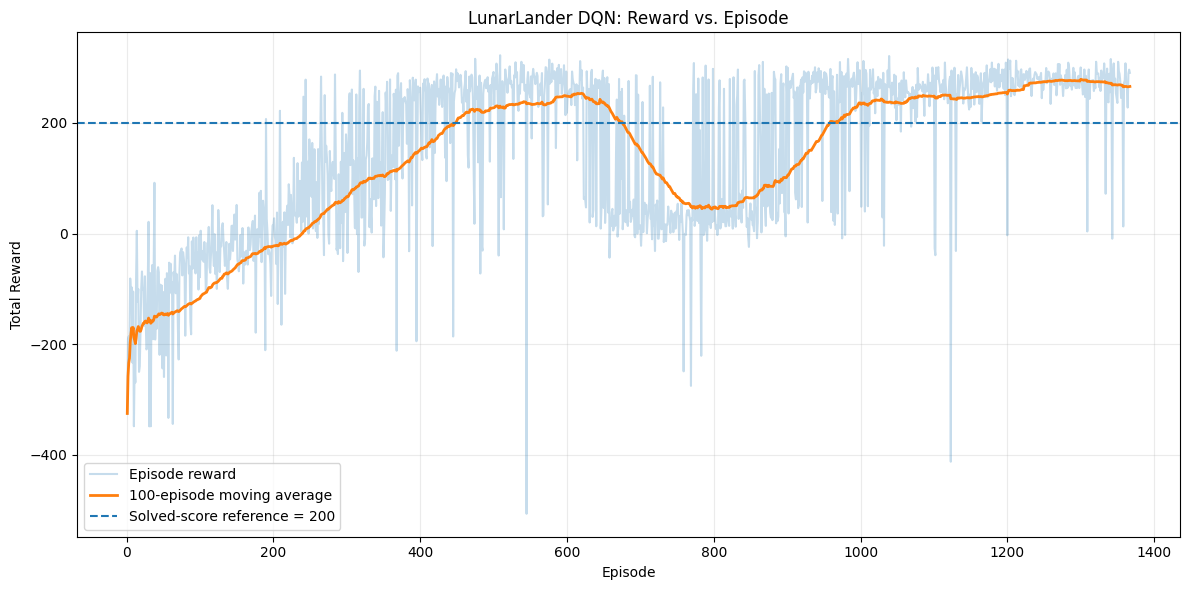

In [18]:
WINDOW = 100
reward_ma = history_df["total_reward"].rolling(WINDOW, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(history_df["episode"], history_df["total_reward"],
         alpha=0.25, label="Episode reward")
plt.plot(history_df["episode"], reward_ma,
         linewidth=2, label="100-episode moving average")
plt.axhline(200, linestyle="--", label="Solved-score reference = 200")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("LunarLander DQN: Reward vs. Episode")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 16. Episode length

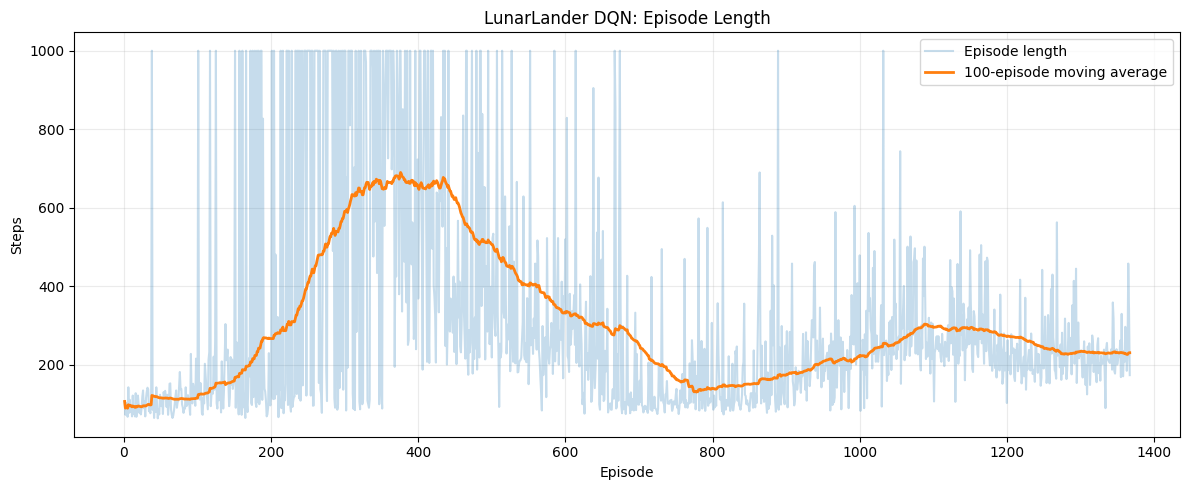

In [19]:
length_ma = history_df["episode_length"].rolling(WINDOW, min_periods=1).mean()

plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["episode_length"],
         alpha=0.25, label="Episode length")
plt.plot(history_df["episode"], length_ma,
         linewidth=2, label="100-episode moving average")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("LunarLander DQN: Episode Length")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 17. Exploration, Q-value, TD error, and loss

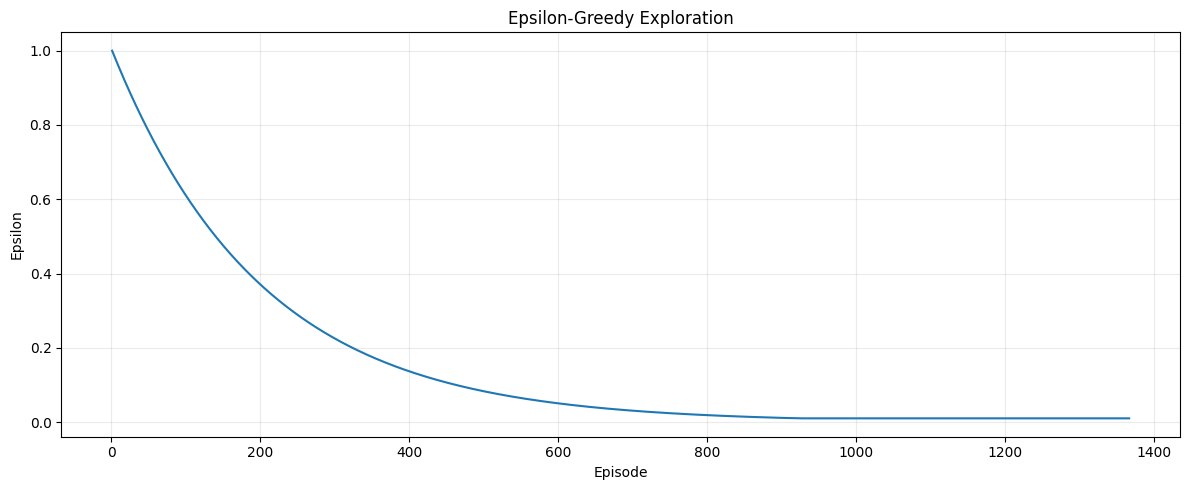

In [20]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["epsilon"])
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.title("Epsilon-Greedy Exploration")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

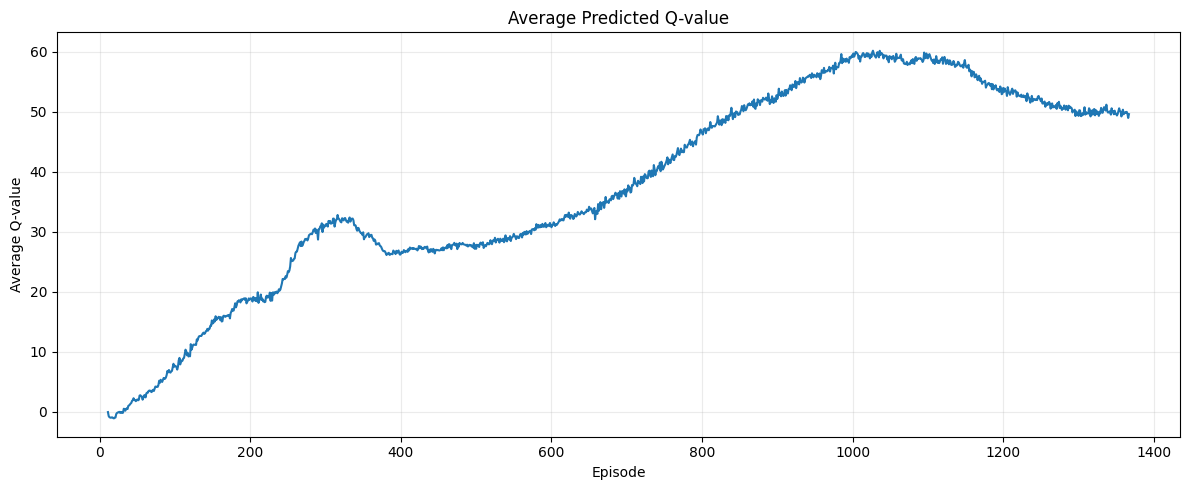

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["average_q"])
plt.xlabel("Episode")
plt.ylabel("Average Q-value")
plt.title("Average Predicted Q-value")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

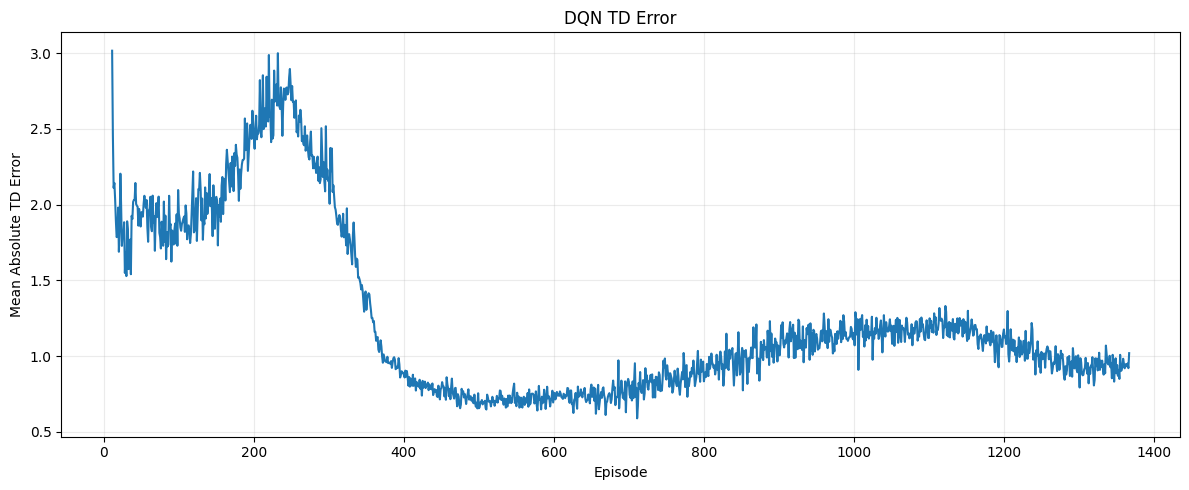

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["td_error"])
plt.xlabel("Episode")
plt.ylabel("Mean Absolute TD Error")
plt.title("DQN TD Error")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

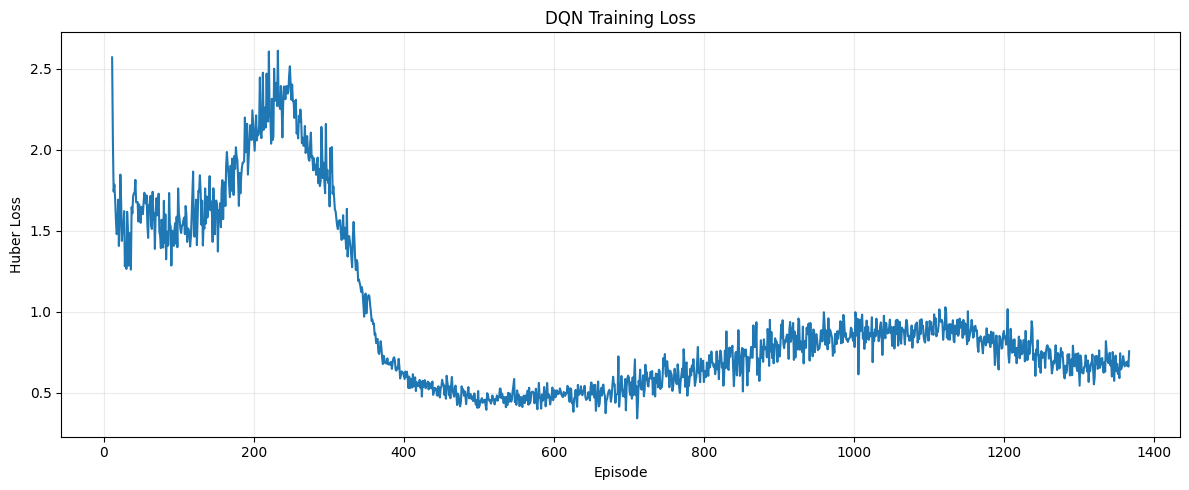

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], history_df["loss"])
plt.xlabel("Episode")
plt.ylabel("Huber Loss")
plt.title("DQN Training Loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 18. Rolling solved-score rate

Training episodes contain exploration, so this is only a diagnostic. Greedy evaluation later is the better final performance measure.

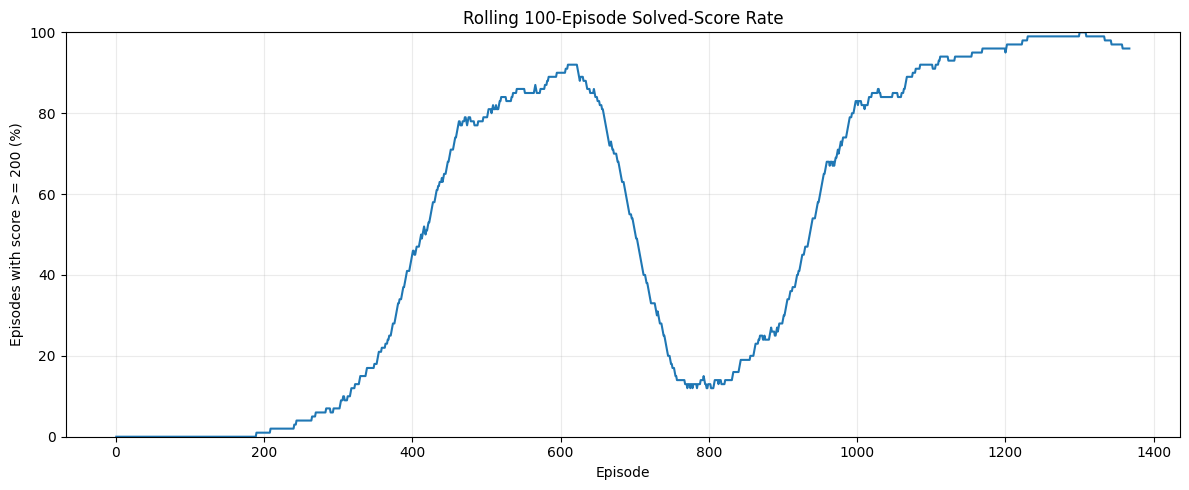

In [24]:
solved = (history_df["total_reward"] >= 200).astype(int)
success_rate = solved.rolling(100, min_periods=1).mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(history_df["episode"], success_rate)
plt.xlabel("Episode")
plt.ylabel("Episodes with score >= 200 (%)")
plt.title("Rolling 100-Episode Solved-Score Rate")
plt.ylim(0, 100)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 19. Random-policy baseline

In [25]:
def evaluate_random_policy(episodes=20, seed=20_000):
    env = gym.make("LunarLander-v3")
    records = []

    for ep in range(episodes):
        state, info = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0
        steps = 0

        while not done:
            action = env.action_space.sample()
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            steps += 1

        records.append({
            "episode": ep + 1,
            "total_reward": total_reward,
            "episode_length": steps
        })

    env.close()
    return pd.DataFrame(records)

random_eval_df = evaluate_random_policy()
display(random_eval_df)

print("Random mean reward:", random_eval_df["total_reward"].mean())

,episode,total_reward,episode_length
0,1,-164.010718,84
1,2,-424.136483,88
2,3,-144.162087,78
3,4,-98.368461,68
4,5,-117.062164,80
5,6,-170.955723,94
6,7,-166.110411,119
7,8,-382.890095,104
8,9,-100.121711,106
9,10,-154.534637,67


Random mean reward: -150.98004438648857


## 20. Greedy evaluation

For final evaluation, exploration is disabled:

$$
\boxed{A_t=\arg\max_a Q(S_t,a;\theta)}
$$

In [26]:
def evaluate_agent(agent, episodes=20, seed=30_000):
    env = gym.make("LunarLander-v3")
    records = []

    for ep in range(episodes):
        state, info = env.reset(seed=seed + ep)
        done = False
        total_reward = 0.0
        steps = 0

        while not done:
            action = agent.select_action(state, training=False)
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            total_reward += reward
            steps += 1

        records.append({
            "episode": ep + 1,
            "total_reward": total_reward,
            "episode_length": steps,
            "score_ge_200": total_reward >= 200
        })

    env.close()
    return pd.DataFrame(records)

evaluation_df = evaluate_agent(agent)
display(evaluation_df)

print("Mean reward:", evaluation_df["total_reward"].mean())
print("Reward SD:", evaluation_df["total_reward"].std())
print("Mean episode length:", evaluation_df["episode_length"].mean())
print("Score >= 200 rate:", f'{100*evaluation_df["score_ge_200"].mean():.1f}%')

,episode,total_reward,episode_length,score_ge_200
0,1,271.595326,202,True
1,2,304.598131,230,True
2,3,285.120948,223,True
3,4,277.582460,186,True
4,5,311.054821,348,True
5,6,296.648673,314,True
6,7,301.093192,223,True
7,8,317.755273,215,True
8,9,272.950285,270,True
9,10,245.801946,234,True


Mean reward: 284.64690281152787
Reward SD: 22.27305216333534
Mean episode length: 232.45
Score >= 200 rate: 100.0%


## 21. Random vs. trained DQN

,Policy,Mean Reward,Mean Episode Length
0,Random,-150.980044,79.20
1,Trained DQN,284.646903,232.45


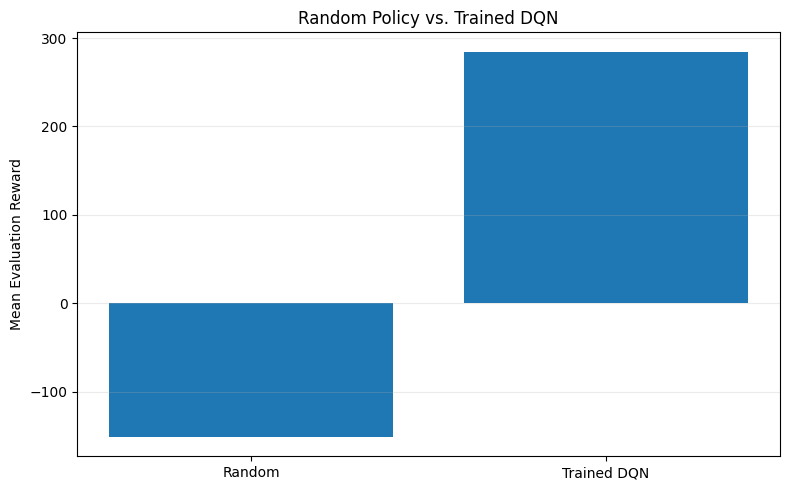

In [27]:
comparison_df = pd.DataFrame({
    "Policy": ["Random", "Trained DQN"],
    "Mean Reward": [
        random_eval_df["total_reward"].mean(),
        evaluation_df["total_reward"].mean()
    ],
    "Mean Episode Length": [
        random_eval_df["episode_length"].mean(),
        evaluation_df["episode_length"].mean()
    ]
})

display(comparison_df)

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Policy"], comparison_df["Mean Reward"])
plt.ylabel("Mean Evaluation Reward")
plt.title("Random Policy vs. Trained DQN")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 22. Inspect learned Q-values

In [28]:
inspect_env = gym.make("LunarLander-v3")
state, info = inspect_env.reset(seed=123)

q_values = agent.q_network(
    tf.convert_to_tensor(state[None, :], dtype=tf.float32),
    training=False
).numpy()[0]

action_names = {
    0: "Do nothing",
    1: "Fire left orientation engine",
    2: "Fire main engine",
    3: "Fire right orientation engine"
}

best_action = int(np.argmax(q_values))

print("State:", state)
print()

for a, q in enumerate(q_values):
    print(f"Action {a}: Q = {q:8.4f} | {action_names[a]}")

print("\nGreedy action:", best_action, "->", action_names[best_action])

inspect_env.close()

State: [ 0.00517693  1.4033939   0.52433753 -0.3345171  -0.00599183 -0.11877016
  0.          0.        ]

Action 0: Q =  94.0529 | Do nothing
Action 1: Q =  94.4327 | Fire left orientation engine
Action 2: Q =  92.7650 | Fire main engine
Action 3: Q =  93.7989 | Fire right orientation engine

Greedy action: 1 -> Fire left orientation engine


## 23. Save and reload the trained agent

In [29]:
agent.save(AGENT_PATH)

loaded_agent = DQNAgent()
loaded_agent.load(AGENT_PATH)

print("Restored epsilon:", loaded_agent.epsilon)
print("Restored environment steps:", loaded_agent.environment_steps)
print("Restored gradient steps:", loaded_agent.gradient_steps)

Restored epsilon: 0.01
Restored environment steps: 420948
Restored gradient steps: 419948


## 24. Record a greedy evaluation episode

In [30]:
def record_episode(agent, filename="lunar_lander_dqn.mp4", seed=40_000, fps=50):
    env = gym.make("LunarLander-v3", render_mode="rgb_array")
    state, info = env.reset(seed=seed)

    frames = [env.render()]
    done = False
    total_reward = 0.0
    steps = 0

    while not done:
        action = agent.select_action(state, training=False)
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        frames.append(env.render())
        total_reward += reward
        steps += 1

    env.close()

    imageio.mimsave(filename, frames, fps=fps)

    print("Video:", filename)
    print("Reward:", total_reward)
    print("Episode length:", steps)

    return filename

video_file = record_episode(agent)
display(Video(video_file, embed=True))

Video: lunar_lander_dqn.mp4
Reward: 267.46051488722867
Episode length: 280


## 25. DQN algorithm

```text
Input:
    environment
    online network Q(s,a;theta)
    target network Q(s,a;theta-)
    replay memory D
    discount factor gamma
    exploration epsilon

Initialize:
    theta randomly
    theta- = theta
    D = empty

For each episode:

    Reset environment and observe S

    Repeat until terminal:

        With probability epsilon:
            choose random action A
        Otherwise:
            A = argmax_a Q(S,a;theta)

        Execute A
        Observe R, S', done

        Store (S,A,R,S',done) in D

        Sample random mini-batch from D

        For each transition:
            Y = R + gamma(1-done)
                      max_a' Q(S',a';theta-)

            Q_pred = Q(S,A;theta)

        Update theta to reduce Loss(Y,Q_pred)

        Periodically:
            theta- <- theta

        S <- S'

    Decay epsilon

Output:
    trained Q-network
```

## 26. Complete data flow

$$
\boxed{
S_t
\rightarrow
Q(S_t,\cdot;\theta)
\rightarrow
A_t
\rightarrow
R_{t+1},S_{t+1}
\rightarrow
\mathcal D
\rightarrow
Y_t
\rightarrow
\delta_t
\rightarrow
\theta\text{ update}
}
$$

The neural network does **not** directly output the action. It outputs four Q-values. The policy selects an action from those Q-values.

Thus DQN changes

$$
\boxed{
\text{Q-table}
\longrightarrow
\text{neural-network Q-function}
}
$$

## 27. interpretation

This demonstrates deep value-based reinforcement learning, continuous-state representation, discrete control, experience replay, target-network stabilization, off-policy TD learning, neural-network optimization, checkpointing, quantitative evaluation, and simulation visualization.

For the final discussion, report the **greedy evaluation mean reward and standard deviation**, not only the best training reward. Training episodes remain noisy because epsilon-greedy exploration deliberately takes random actions.

## References

1. Mnih, V., Kavukcuoglu, K., Silver, D., et al. (2015). **Human-level control through deep reinforcement learning.** *Nature*, 518, 529–533. https://doi.org/10.1038/nature14236

2. Gymnasium: **Lunar Lander** — https://gymnasium.farama.org/environments/box2d/lunar_lander/

3. Gymnasium: **Box2D environments** — https://gymnasium.farama.org/environments/box2d/